In [2]:
import pandas
#import matplotlib.pyplot as plt

In [3]:
# https://vizier.cds.unistra.fr/viz-bin/VizieR-4
file = "data_clean/vizier_I_239_hip_main_LimpiezaNaNPlx.tsv"

# leer .tsv
df = pandas.read_csv(
    file,              # nombre y ruta del archivo
    sep = '\t',         # símbolo de separación de columnas
    nrows = 118218,    # número de filas que se leerán
    index_col = 'HIP', # nombre de la columna índice
)

# dataframe
print( type(df) )

df

<class 'pandas.core.frame.DataFrame'>


,recno,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAICRS,DEICRS,AstroRef,...,BD,CoD,CPD,(V-I)red,SpType,r_SpType,HIPep,Erratum,_RA.icrs,_DE.icrs
HIP,,,,,,,,,,,,,,,,,,,,,
1,1,NaN,00 00 00.22,+01 05 20.4,9.10,NaN,H,0.000912,1.089013,NaN,...,B+00 5077,NaN,NaN,0.66,F5,S,HIPep,Erratum,0.000899,1.089009
2,2,NaN,00 00 00.91,-19 29 55.8,9.27,NaN,G,0.003797,-19.498837,+,...,B-20 6688,NaN,NaN,1.04,K3V,4,HIPep,Erratum,0.004265,-19.498840
3,3,NaN,00 00 01.20,+38 51 33.4,6.61,NaN,G,0.005008,38.859286,NaN,...,B+38 5108,NaN,NaN,0.00,B9,S,HIPep,Erratum,0.005024,38.859279
4,4,NaN,00 00 02.01,-51 53 36.8,8.06,NaN,H,0.008382,-51.893546,NaN,...,NaN,NaN,P-52 12237,0.43,F0V,2,HIPep,Erratum,0.008629,-51.893546
5,5,NaN,00 00 02.39,-40 35 28.4,8.55,NaN,H,0.009965,-40.591224,NaN,...,NaN,C-41 15372,P-41 9991,0.95,G8III,2,HIPep,Erratum,0.009973,-40.591202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118318,118214,NaN,23 59 51.30,+11 40 25.4,6.99,1.0,H,359.963744,11.673709,NaN,...,B+10 5018,NaN,NaN,1.56,K2,S,HIPep,Erratum,359.963738,11.673714
118319,118215,NaN,23 59 53.74,-22 25 41.4,8.23,NaN,G,359.973913,-22.428180,NaN,...,NaN,C-23 18108,P-23 8366,0.70,G2V,4,HIPep,Erratum,359.974304,-22.428113
118320,118216,NaN,23 59 54.25,+05 57 23.9,7.59,NaN,H,359.976057,5.956638,NaN,...,B+05 5245,NaN,NaN,0.98,K0,S,HIPep,Erratum,359.976109,5.956552


In [4]:
# agrupar las magnitudes por orden en rango
min_vmag = int( df['Vmag'].min() )
max_vmag = int( df['Vmag'].max() )

# frecuencia de las magnitudes
vmag_freq = df['Vmag'].value_counts( 
    bins = range( min_vmag - 5, max_vmag ) 
).sort_index()

print(min_vmag, max_vmag)

vmag_freq

-1 13


(-6.001, -5.0]        0
(-5.0, -4.0]          0
(-4.0, -3.0]          0
(-3.0, -2.0]          0
(-2.0, -1.0]          1
(-1.0, 0.0]           3
(0.0, 1.0]           11
(1.0, 2.0]           34
(2.0, 3.0]          128
(3.0, 4.0]          340
(4.0, 5.0]         1103
(5.0, 6.0]         3397
(6.0, 7.0]        10402
(7.0, 8.0]        25527
(8.0, 9.0]        40746
(9.0, 10.0]       23124
(10.0, 11.0]       6649
(11.0, 12.0]       1870
Name: count, dtype: int64

In [34]:
vmag_freq.index = range(min_vmag - 4, max_vmag)
vmag_freq

-5        0
-4        0
-3        0
-2        0
-1        1
0         3
1        11
2        34
3       128
4       341
5      1107
6      3416
7     10496
8     25857
9     41943
10    24546
11     7396
12     2183
13      471
Name: count, dtype: int64

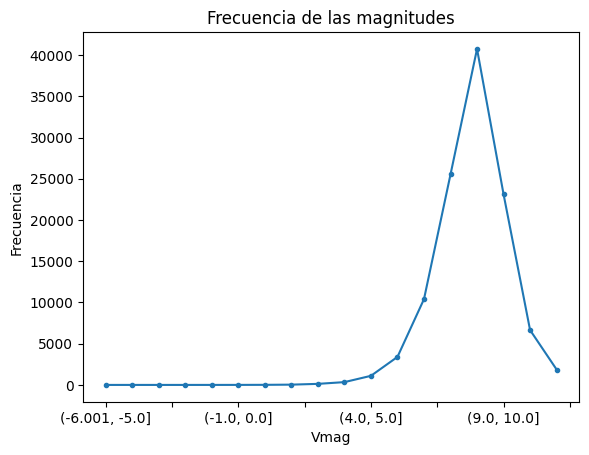

In [5]:
import matplotlib.pyplot as plt

vmag_freq.plot(
    style = '.-', title = 'Frecuencia de las magnitudes',
    xlabel = 'Vmag', ylabel = 'Frecuencia'
)

plt.show()

In [8]:
df["Vmag"].describe()

count    113710.000000
mean          8.330849
std           1.295276
min          -1.440000
25%           7.612500
50%           8.410000
75%           9.100000
max          13.570000
Name: Vmag, dtype: float64

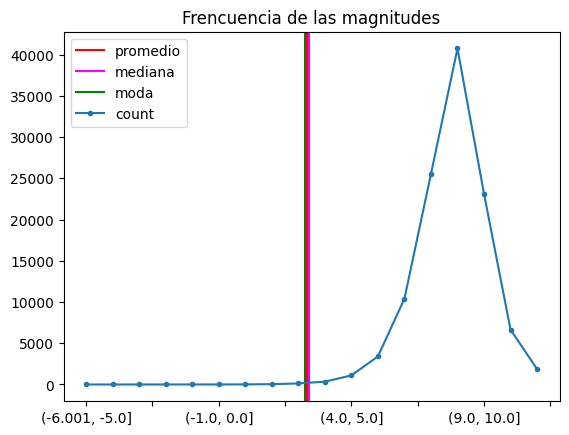

In [10]:
# Gráficas de las medidas estadísticas
plt.axvline( df['Vmag'].mean(), color = 'red', label = 'promedio' )

plt.axvline( df['Vmag'].median(), color = 'magenta', label = 'mediana' )

plt.axvline( df['Vmag'].mode()[0], color ='green', label = 'moda' )

# Gráfica de la frecuencia de las edades
vmag_freq.plot( style = ".-", title = 'Frencuencia de las magnitudes' )

# Leyenda y mostrar gráfica
plt.legend()

plt.show()

In [11]:
df['Vmag'].skew()

np.float64(-0.41269775835454836)

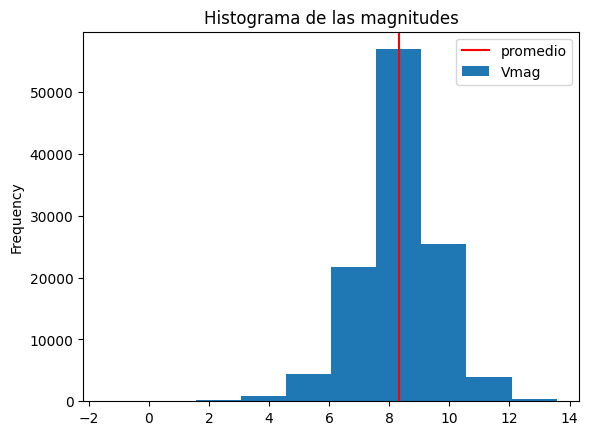

In [12]:
# Gráficas de las medidas estadísticas
plt.axvline( df['Vmag'].mean(), color = 'red', label = 'promedio' )

# Gráfica de la frecuencia de las edades
df['Vmag'].plot.hist( title = 'Histograma de las magnitudes' )

# Leyenda y mostrar gráfica
plt.legend()
plt.show()

In [13]:
df['Vmag'].std()

np.float64(1.2952760488062454)

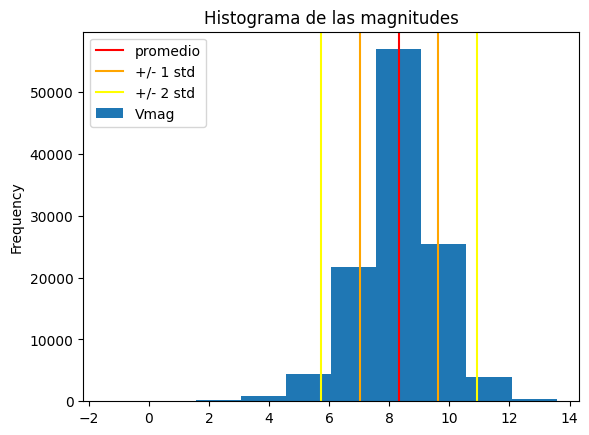

In [14]:
# Gráficas de las medidas estadísticas
plt.axvline( df['Vmag'].mean(), color = 'red', label = 'promedio' )
plt.axvline( df['Vmag'].mean() + df['Vmag'].std(), color = 'orange', label = '+/- 1 std' )
plt.axvline( df['Vmag'].mean() - df['Vmag'].std(), color = 'orange' )
plt.axvline( df['Vmag'].mean() + df['Vmag'].std() * 2, color = 'yellow', label = '+/- 2 std' )
plt.axvline( df['Vmag'].mean() - df['Vmag'].std() * 2, color = 'yellow' )

# Gráfica de la frecuencia de las edades
df['Vmag'].plot.hist( title = 'Histograma de las magnitudes' )

# Leyenda y mostrar gráfica
plt.legend()
plt.show()

## 1. Astronomical Coordinate system

We start by looking at what portion of the sky is covered by the Hipparchos mission. To do this we use the astronomical coordinate systems,

- The right ascension
- The declination

Think of right ascension as the longitude and declination as the latitude of the stars in the sky with respect to what Astronomers define the [celestial sphere](https://en.wikipedia.org/wiki/Celestial_sphere), an imaginary sphere at infinity such that stars at these distance appear to remain fixed in the sky.

[This is](https://skyandtelescope.org/astronomy-resources/right-ascension-declination-celestial-coordinates/) an article by one of our fellow astronomers. I strongly recommend you to read it through if you are new to Astronomy.

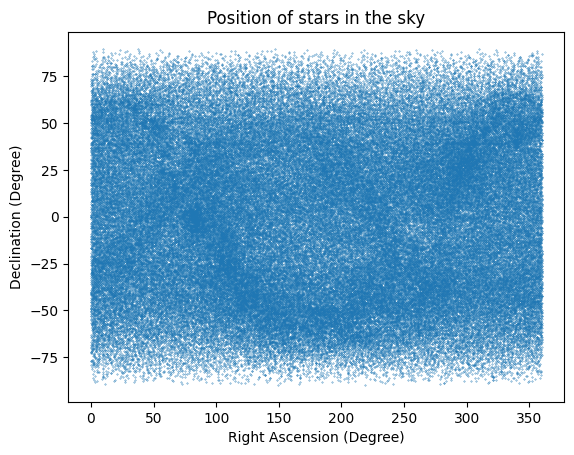

In [59]:
# estilo para las figuras
newfigparams = {
    "figure.figsize": (10,4),
    "figure.dpi": 150,
    "axes.titlesize": 20,
    "axes.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11,
    "legend.fontsize": 12,
    "legend.frameon": True,
    "lines.linewidth": 1
}
#plt.rcParams.update(newfigparams)
#plt.style.use("dark_background")

fig, ax = plt.subplots()
ax.plot(df["RAICRS"], df["DEICRS"], 'o', markersize = 0.3)
#ax.plot(x, y)

plt.xlabel("Right Ascension (Degree)")
plt.ylabel("Declination (Degree)")
plt.title ("Position of stars in the sky")

plt.show()

The stars in the catalogue covers pretty much the entire sky. Notice that in the plot we see regions of over densities and underdensities. These are very common terms used in Astronomy to see how well is the sky covered by a particular mission. I will not go any deeper into these concepts here. For the time being, consider over densities as regions where you see more stars than the average and the underdensities as regions where you see lesser number of stars than the average.

## 2. Proper Motion of stars

We now visualize the proper motion of the stars as captured by the Hipparchos mission.

Distant stars on the celestial sphere appear to remain fixed, however, most of the stars in the solar neighborhood appear to move across the celestial sphere since these stars are closer. This apparent motion of stars with respect to the fixed stars in the background is called the [proper motion](https://en.wikipedia.org/wiki/Proper_motion).

Proper motion is measured along the Right Ascension (pmRA) and along the Declination (pmDE) and these are measured in mas per year (mas year−1), where mas is milliarcseconds, a common unit used to measure very small angles in the sky.

1mas=10−3arcsecond

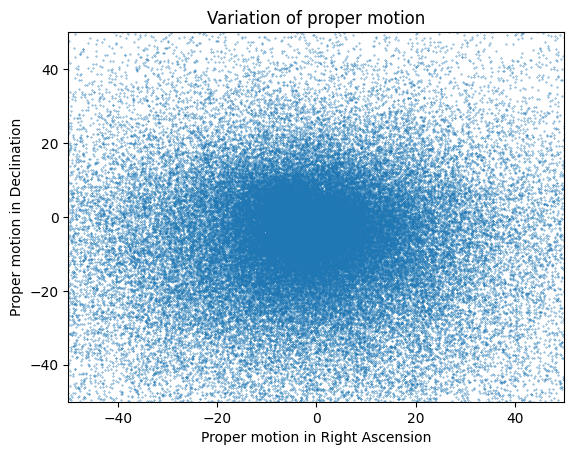

In [60]:
plt.plot(df["pmRA"], df["pmDE"], 'o', markersize = 0.3)
plt.xlabel("Proper motion in Right Ascension")
plt.ylabel("Proper motion in Declination")
plt.title ("Variation of proper motion")
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.show()



Could you think of a reason why the proper motion is centered around 0?

[Think in terms of earth's motion in the solar system and the solar system's motion around the galactic center]
